In [3]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("hospital_patient_dataset.csv")
print(df.head())
print(df.describe())
print("column types + null info==========",df.info())









   patient_id  age  gender       disease     department admission_date  \
0           1   36    Male      Diabetes  Endocrinology     2024-01-26   
1           2   70    Male  Hypertension     Cardiology     2024-04-14   
2           3   12    Male      Fracture    Orthopedics     2024-02-02   
3           4   72    Male        Cancer       Oncology     2025-09-08   
4           5   76  Female      Fracture    Orthopedics     2024-08-13   

  discharge_date  treatment_cost_usd  
0     2024-02-07                7514  
1     2024-04-25               19549  
2     2024-02-03                7823  
3     2025-09-09               18056  
4     2024-08-21                 412  
         patient_id           age  treatment_cost_usd
count  50000.000000  50000.000000        50000.000000
mean   25000.500000     45.479500        10060.337540
std    14433.901067     25.972367         5725.136385
min        1.000000      1.000000          200.000000
25%    12500.750000     23.000000         5089.0000

In [4]:
# data cleaning 
df['admission_date']= pd.to_datetime(df['admission_date'])
print(df.head())
df['discharge_date']= pd.to_datetime(df["discharge_date"])

   patient_id  age  gender       disease     department admission_date  \
0           1   36    Male      Diabetes  Endocrinology     2024-01-26   
1           2   70    Male  Hypertension     Cardiology     2024-04-14   
2           3   12    Male      Fracture    Orthopedics     2024-02-02   
3           4   72    Male        Cancer       Oncology     2025-09-08   
4           5   76  Female      Fracture    Orthopedics     2024-08-13   

  discharge_date  treatment_cost_usd  
0     2024-02-07                7514  
1     2024-04-25               19549  
2     2024-02-03                7823  
3     2025-09-09               18056  
4     2024-08-21                 412  


In [5]:


# average age 
avarage_age = df['age'].mean()
print("avarage_age :",avarage_age )

if 'disease' in df.columns:
    print(df['disease'].value_counts())

avarage_age : 45.4795
disease
Stroke            5171
Asthma            5077
Pneumonia         5069
Diabetes          4999
Pregnancy         4996
Hypertension      4968
Fracture          4957
Heart Disease     4927
Kidney Disease    4923
Cancer            4913
Name: count, dtype: int64


In [6]:
# calculate stay daysss ===

df['stay_days']= (df["discharge_date"]-df['admission_date']).dt.days
# pd.to_Excel("hospital.json", index=False sheetname="")
df.to_excel("hospital.xlsx", sheet_name="clean_hospital_data", index=False)
df.to_json("hospital.json", orient="records")
print("check missing values count:==============",df.isnull().sum())
disease_summary = df.groupby('disease').size().reset_index(name='patient_count')

disease_summary.to_excel("hospital.xlsx", sheet_name="Disease_Summary", index=False)

check missing values count:============== patient_id            0
age                   0
gender                0
disease               0
department            0
admission_date        0
discharge_date        0
treatment_cost_usd    0
stay_days             0
dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_22844\602784328.py:6: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  df.to_json("hospital.json", orient="records")


In [7]:

# gender distribution 
gender_count = df['gender'].value_counts()
print("gender count:==========",gender_count)

gender count:========== gender
Female    25024
Male      24976
Name: count, dtype: int64


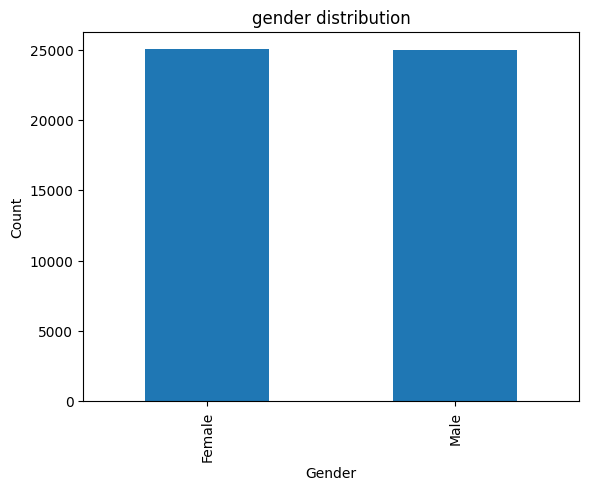

In [8]:
    
gender_count.plot(kind='bar')
plt.title("gender distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.savefig("gender_count.png")
plt.show()

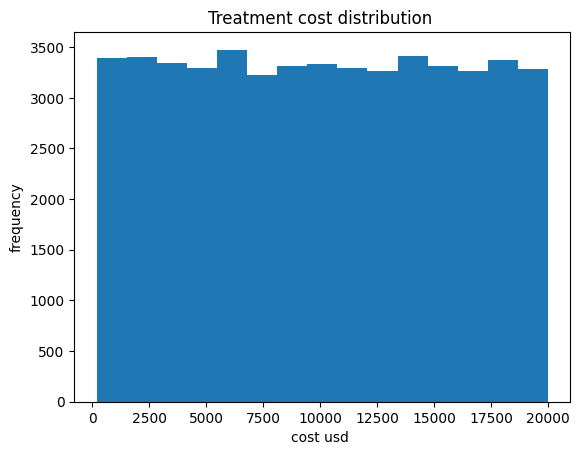

In [9]:
plt.hist(df['treatment_cost_usd'],bins=15)
plt.title("Treatment cost distribution ")
plt.xlabel('cost usd ')
plt.ylabel("frequency")
plt.savefig("treatment_cost.png")
plt.show()

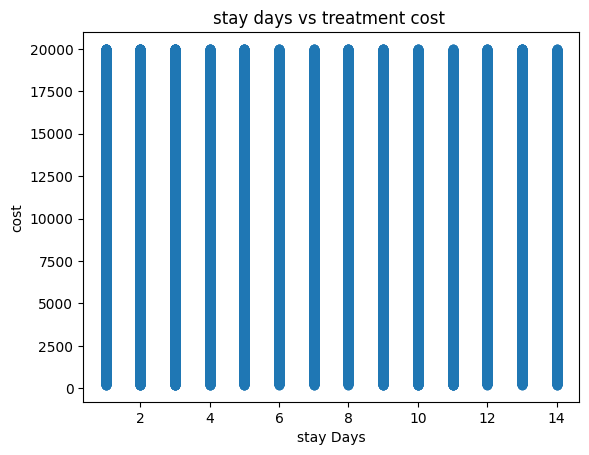

In [10]:
plt.scatter(df['stay_days'],df['treatment_cost_usd'])
plt.title("stay days vs treatment cost ")
plt.xlabel("stay Days")
plt.ylabel("cost")
plt.savefig("stay_vs_treatment_cost.png")
plt.show()

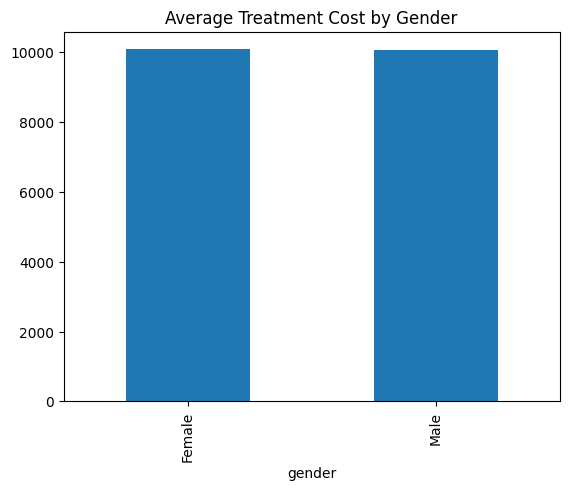

In [11]:
avg_cost_gender = df.groupby("gender")["treatment_cost_usd"].mean()
avg_cost_gender.plot(kind="bar")
plt.title("Average Treatment Cost by Gender")
plt.savefig("avrg_gender.png")
plt.savefig("avrg_treatment_cost_by_gender.png")
plt.show()

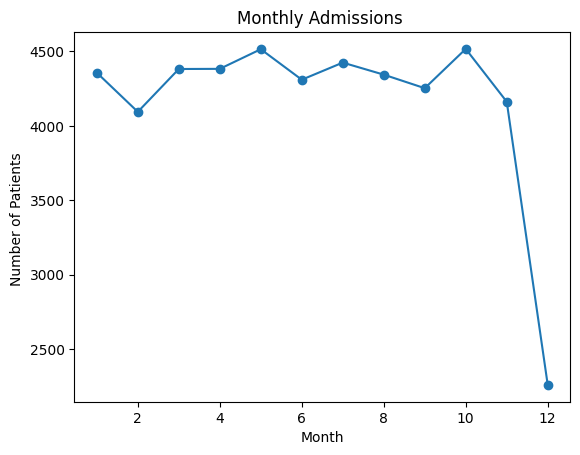

In [12]:
# monthly admission Trend 
df['month']= df['admission_date'].dt.month
monthly = df['month'].value_counts().sort_index()
monthly.plot(kind='line', marker='o')
plt.title("Monthly Admissions ")
plt.xlabel("Month")
plt.ylabel("Number of Patients ")
plt.savefig("monthly_admissions.png")
plt.show()

In [13]:
print(df['treatment_cost_usd'].max())

20000


<Figure size 1200x800 with 0 Axes>

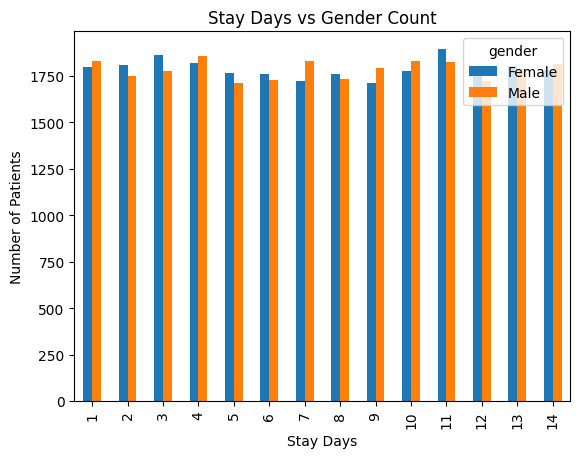

In [14]:


stayCount = df.groupby(['stay_days', 'gender']).size()
stayCount = stayCount.unstack()
plt.figure(figsize=(12, 8)) 
stayCount.plot(kind="bar")
plt.title("Stay Days vs Gender Count")
plt.xlabel("Stay Days")
plt.ylabel("Number of Patients")
plt.savefig("stay_day_vs_gender_count.png")
plt.show()

disease
Asthma            5077
Cancer            4913
Diabetes          4999
Fracture          4957
Heart Disease     4927
Hypertension      4968
Kidney Disease    4923
Pneumonia         5069
Pregnancy         4996
Stroke            5171
dtype: int64


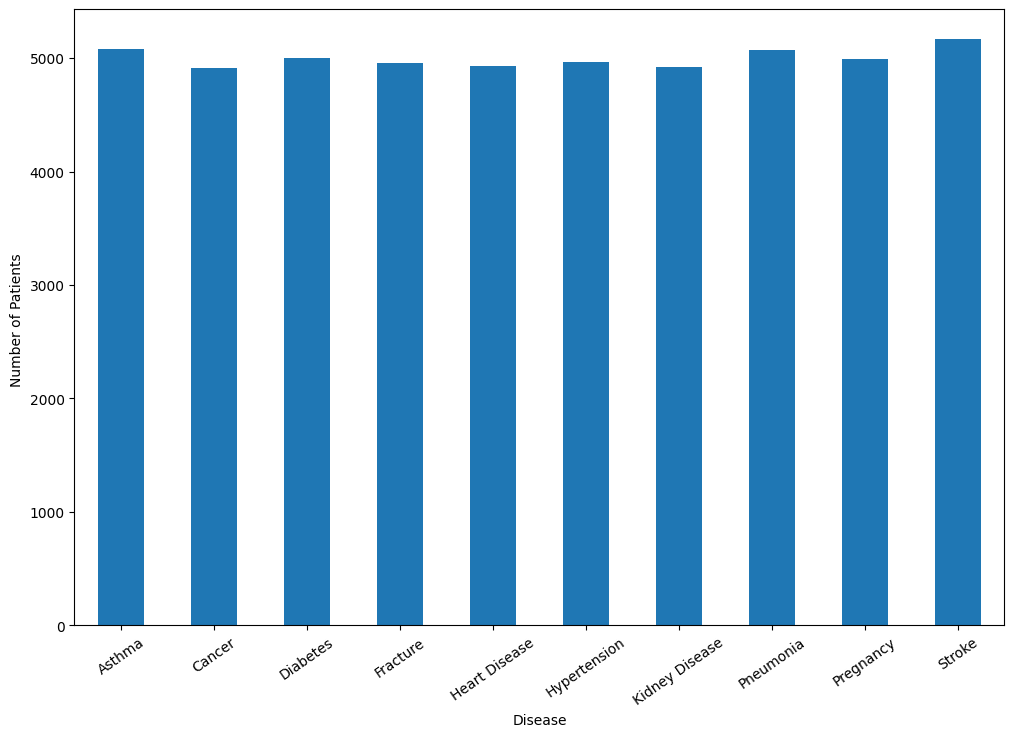

In [16]:
#  Disease-wise patient count
diseas_count = df.groupby("disease").size()
print(diseas_count)
plt.figure(figsize=(12,8))
diseas_count.plot(kind="bar")
plt.xlabel("Disease")
plt.ylabel("Number of Patients ")
plt.xticks(rotation=35)
plt.savefig("disease_count_number_patients.png")
plt.show()